MILP solving: 100%|██████████| 50/50 [00:00<00:00, 51.98it/s]

10.57794612459634


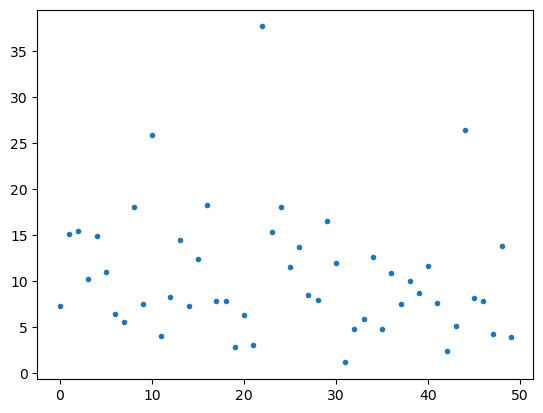

In [3]:
from single.basics import generate_instance, bimodal_exponential
import matplotlib.pyplot as plt
from tqdm import tqdm

F_high = bimodal_exponential(p=0.5, s1=0.1, s2=10.00)
F_low  = bimodal_exponential(p=0.1, s1=0.1, s2= 5.6)
gen = lambda: generate_instance(F_low, [5, 5, 5])

N = 50
instances = [gen() for _ in range(N)]
for s in tqdm(instances, desc="MILP solving"):
    s.solve(cutting_planes=[2,3])

obj = sum([s.opt.delay for s in instances]) / N
print(obj)
plt.plot([s.opt.delay for s in instances], '.')